In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import io

# 1. Load your uploaded dataset or fallback to a realistic synthetic dataset
try:
    df = pd.read_csv('Unemployment_in_India.csv')
    print("Loaded 'Unemployment_in_India.csv' successfully!")
except FileNotFoundError:
    print("Local CSV file not found. Generating sample dataset for testing...")
    np.random.seed(42)
    dates = pd.date_range(start='2019-01-31', end='2020-06-30', freq='M')
    states = ['Maharashtra', 'Delhi', 'Tamil Nadu', 'Uttar Pradesh', 'Bihar',
              'Karnataka', 'West Bengal', 'Gujarat', 'Punjab', 'Rajasthan', 'Haryana']

    data = []
    for d in dates:
        for s in states:
            # Simulate a spike in unemployment around COVID lockdown (March 2020 onwards)
            base_rate = np.random.uniform(4, 12)
            if d >= pd.to_datetime('2020-03-31'):
                base_rate += np.random.uniform(10, 25)

            data.append({
                'Region': s,
                ' Date': d.strftime('%d-%m-%Y'),
                ' Frequency': ' Monthly',
                ' Estimated Unemployment Rate (%)': round(base_rate, 2),
                ' Estimated Employed': np.random.randint(5000000, 25000000),
                ' Estimated Labour Participation Rate (%)': round(np.random.uniform(35, 55), 2),
                'Area': np.random.choice(['Rural', 'Urban'])
            })
    df = pd.DataFrame(data)

# 2. Clean up whitespace from column names
df.columns = df.columns.str.strip()
print("\nDataset Columns:", df.columns.tolist())

Local CSV file not found. Generating sample dataset for testing...

Dataset Columns: ['Region', 'Date', 'Frequency', 'Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)', 'Area']


/tmp/ipykernel_497/2723885697.py:14: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(start='2019-01-31', end='2020-06-30', freq='M')


In [2]:
# Check for null values and drop them if present
df = df.dropna()

# Convert Date column to pandas datetime object
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Extract temporal variables
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month_name()

# Categorize Pre-COVID vs. Post-COVID periods (Cutoff: March 1, 2020)
covid_cutoff = pd.to_datetime('2020-03-01')
df['Period'] = np.where(df['Date'] < covid_cutoff, 'Pre-COVID', 'Post-COVID (Pandemic Impact)')

# Display clean dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198 entries, 0 to 197
Data columns (total 10 columns):
 #   Column                                   Non-Null Count  Dtype         
---  ------                                   --------------  -----         
 0   Region                                   198 non-null    object        
 1   Date                                     198 non-null    datetime64[ns]
 2   Frequency                                198 non-null    object        
 3   Estimated Unemployment Rate (%)          198 non-null    float64       
 4   Estimated Employed                       198 non-null    int64         
 5   Estimated Labour Participation Rate (%)  198 non-null    float64       
 6   Area                                     198 non-null    object        
 7   Year                                     198 non-null    int32         
 8   Month                                    198 non-null    object        
 9   Period                                   19

/tmp/ipykernel_497/4042955995.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_unemp.index, y=region_unemp.values, palette='viridis')


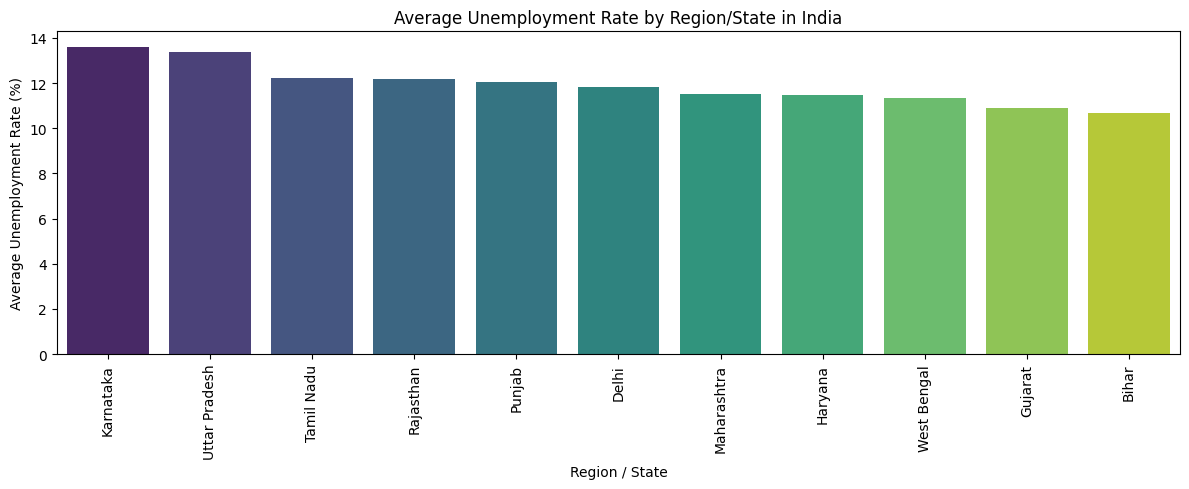

In [3]:
plt.figure(figsize=(12, 5))
region_unemp = df.groupby('Region')['Estimated Unemployment Rate (%)'].mean().sort_values(ascending=False)
sns.barplot(x=region_unemp.index, y=region_unemp.values, palette='viridis')
plt.xticks(rotation=90)
plt.title('Average Unemployment Rate by Region/State in India')
plt.xlabel('Region / State')
plt.ylabel('Average Unemployment Rate (%)')
plt.tight_layout()
plt.show()

/tmp/ipykernel_497/2805724653.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_10.values, y=top_10.index, palette='magma')


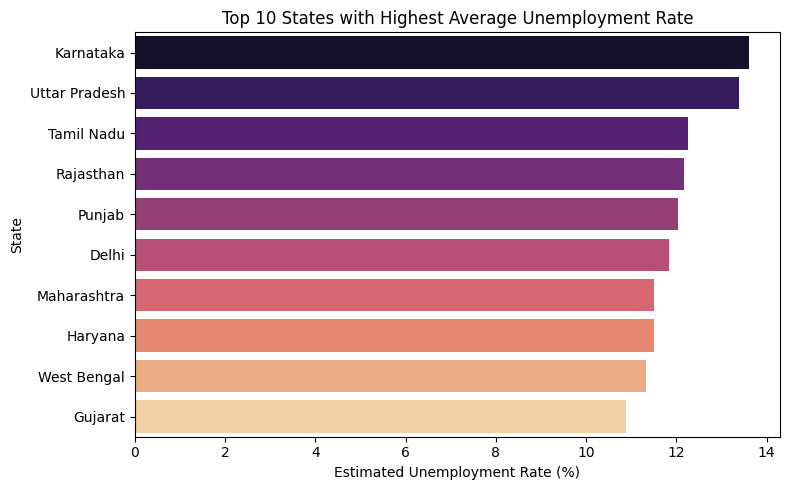

In [4]:
plt.figure(figsize=(8, 5))
top_10 = region_unemp.head(10)
sns.barplot(x=top_10.values, y=top_10.index, palette='magma')
plt.title('Top 10 States with Highest Average Unemployment Rate')
plt.xlabel('Estimated Unemployment Rate (%)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

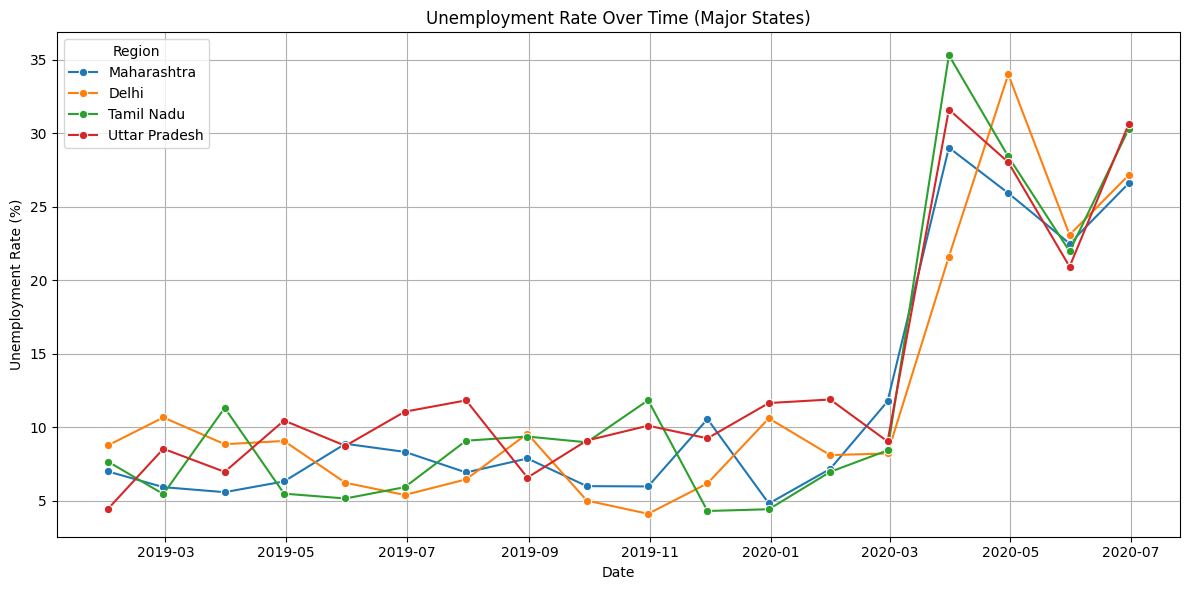

In [5]:
selected_states = ['Maharashtra', 'Delhi', 'Tamil Nadu', 'Uttar Pradesh']
df_filtered = df[df['Region'].isin(selected_states)]

plt.figure(figsize=(12, 6))
sns.lineplot(data=df_filtered, x='Date', y='Estimated Unemployment Rate (%)', hue='Region', marker='o')
plt.title('Unemployment Rate Over Time (Major States)')
plt.xlabel('Date')
plt.ylabel('Unemployment Rate (%)')
plt.grid(True)
plt.tight_layout()
plt.show()

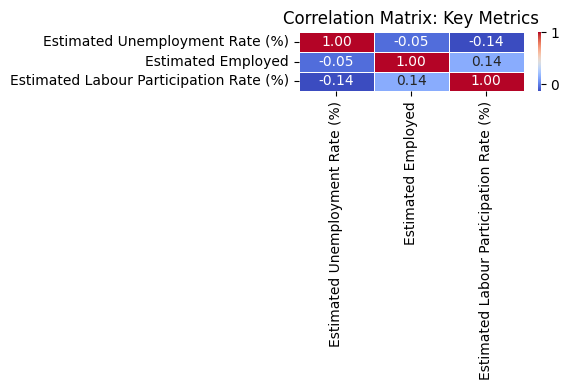

In [6]:
plt.figure(figsize=(6, 4))
numeric_cols = df[['Estimated Unemployment Rate (%)', 'Estimated Employed', 'Estimated Labour Participation Rate (%)']]
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix: Key Metrics')
plt.tight_layout()
plt.show()

/tmp/ipykernel_497/3772033854.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Period', y='Estimated Unemployment Rate (%)', data=df, palette='Set2', errorbar=None)


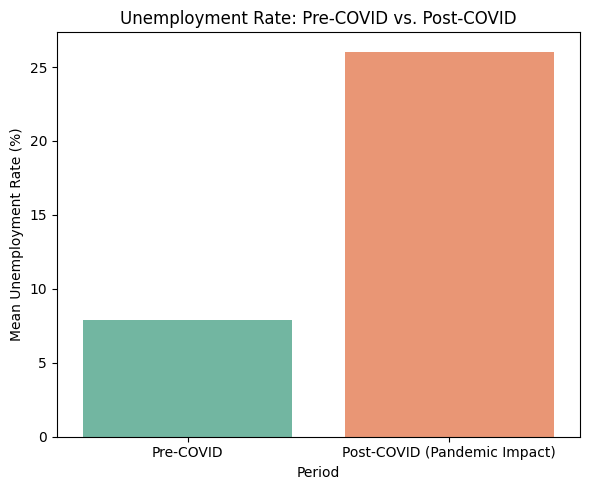


Mean Unemployment Rate by Period:
Period
Post-COVID (Pandemic Impact)    26.05
Pre-COVID                        7.89
Name: Estimated Unemployment Rate (%), dtype: float64


In [7]:
plt.figure(figsize=(6, 5))
sns.barplot(x='Period', y='Estimated Unemployment Rate (%)', data=df, palette='Set2', errorbar=None)
plt.title('Unemployment Rate: Pre-COVID vs. Post-COVID')
plt.ylabel('Mean Unemployment Rate (%)')
plt.tight_layout()
plt.show()

# Print exact stats for Markdown report[cite: 1]
print("\nMean Unemployment Rate by Period:")
print(df.groupby('Period')['Estimated Unemployment Rate (%)'].mean().round(2))